#1.º Modelo - InceptionV3

##Importar Bibliotecas

In [ ]:
# bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array

##Carregar Dataset e visualizar alguns dados exemplo

In [ ]:
import os
import zipfile

# Caminho do arquivo ZIP e da pasta de destino
zip_path = '/content/Frutas.v2-version-2_70-20-10-pos-dataaugmentation.folder.zip'
destination_folder = '/content/Frutas'

# Verificar se o arquivo ZIP existe
if not os.path.exists(zip_path):
    print(f"Erro: O arquivo ZIP '{zip_path}' não foi encontrado.")
else:
    # Criar a pasta de destino, se ainda não existir
    os.makedirs(destination_folder, exist_ok=True)

    try:
        # Verificar se o arquivo é um ZIP válido
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f"Arquivos descompactados em: {destination_folder}")
    except zipfile.BadZipFile:
        print(f"Erro: O arquivo '{zip_path}' não é um arquivo ZIP válido.")
    except Exception as e:
        print(f"Ocorreu um erro ao descompactar o arquivo: {e}")

Arquivos descompactados em: /content/Frutas


In [ ]:
input_size = (320, 320)

# Carregar imagens
train_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Frutas/train",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

val_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Frutas/valid",
    seed=393,
    image_size=input_size,
    label_mode='categorical'
)

test_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Frutas/test",
    seed=196,
    image_size=input_size,
    label_mode='categorical'
)

# Classes
class_names = train_set.class_names

Found 1377 files belonging to 5 classes.
Found 393 files belonging to 5 classes.
Found 196 files belonging to 5 classes.


In [ ]:
images_by_class = {class_name: [] for class_name in class_names}

for images, labels in train_set.take(-1):
    images_np = images.numpy().astype("uint8")
    labels_np = labels.numpy()

    for img, label in zip(images_np, labels_np):
        class_idx = tf.argmax(label).numpy()
        class_name = class_names[class_idx]

        if len(images_by_class[class_name]) < 5:
            images_by_class[class_name].append(img)

    if all(len(img_list) == 5 for img_list in images_by_class.values()):
        break

for class_name, images in images_by_class.items():
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_name}", fontsize=16)
    for i, img in enumerate(images):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

##Normalização e inicialização do modelo

In [ ]:
# Normalização das imagens
train_set = train_set.map(lambda x, y: (x / 255.0, y))
val_set = val_set.map(lambda x, y: (x / 255.0, y))
test_set = test_set.map(lambda x, y: (x / 255.0, y))

In [ ]:
# Inicializar modelo
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False  # congelar o modelo

# adicionar uma nova layer de saída ao modelo, para classificar as classes corretas
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(5, activation='softmax')  # 5 classes
])

# compilar modelo
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Exibir o resumo do modelo
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 8, 8, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │          10,245 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,813,029 (83.21 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Early stopping callback para parar o treino quando não existe melhoria da validation loss
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,               # pára o treino após 5 épocas
    restore_best_weights=True # reverter os pesos do treino para os melhores obtidos
)

# Reduce learning rate callback para atualizar o learning rate quando não existe melhoria da validation loss
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,               # reduzir learning rate por um fator de 0.1
    patience=3,               # atualiza após 3 épocas
    min_lr=1e-10              # learning rate mínimo
)

model_checkpoint = ModelCheckpoint('/content/model_checkpoint.keras', save_best_only=True, monitor='val_loss', mode='min'),


##Treino do Modelo e análise/avaliação de resultados


In [ ]:
# treinar o modelo
history = model.fit(train_set,
                    batch_size = 32,
                    epochs=100,
                    validation_data=val_set,
                    callbacks=[early_stopping, reduce_lr, model_checkpoint])

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 51s 696ms/step - accuracy: 0.2452 - loss: 1.6472 - val_accuracy: 0.5522 - val_loss: 1.3452 - learning_rate: 1.0000e-04
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 176ms/step - accuracy: 0.6612 - loss: 1.1801 - val_accuracy: 0.7710 - val_loss: 1.0715 - learning_rate: 1.0000e-04
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - accuracy: 0.8524 - loss: 0.8759 - val_accuracy: 0.8575 - val_loss: 0.8749 - learning_rate: 1.0000e-04
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.9180 - loss: 0.6830 - val_accuracy: 0.8753 - val_loss: 0.7421 - learning_rate: 1.0000e-04
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 201ms/step - accuracy: 0.9461 - loss: 0.5446 - val_accuracy: 0.8830 - val_loss: 0.6497 - learning_rate: 1.0000e-04
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.9408 - loss: 0.4641 - val_accuracy: 0.8982 - val_loss: 0.5802 - learning_rate: 1.0000e-04
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step -

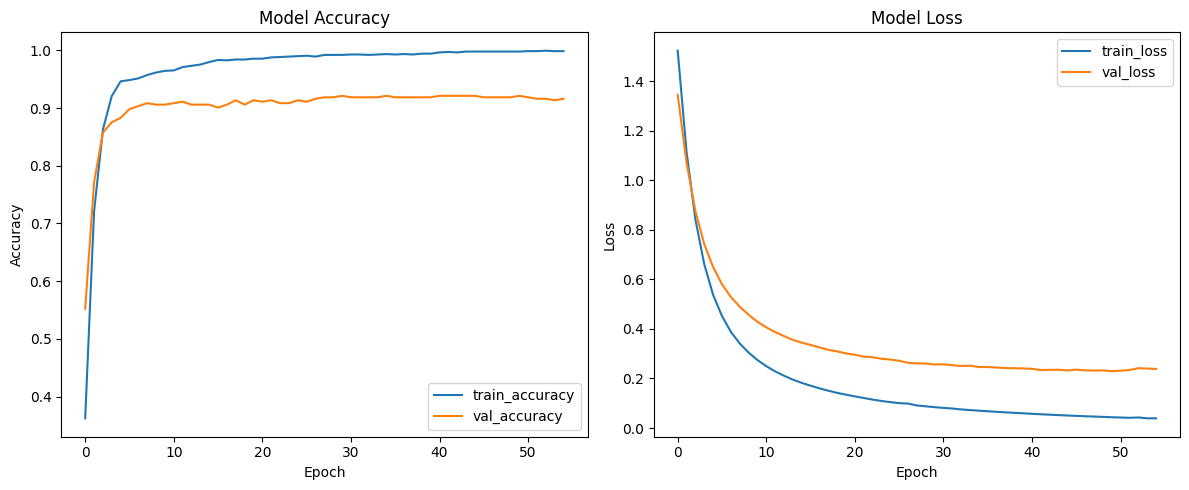

In [ ]:
# criar figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='train_accuracy')
axes[0].plot(history.history['val_accuracy'], label='val_accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Model Accuracy')

# Loss plot
axes[1].plot(history.history['loss'], label='train_loss')
axes[1].plot(history.history['val_loss'], label='val_loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Model Loss')

plt.tight_layout()
plt.show()

In [ ]:
# avaliar treino com base nos dados de teste
test_loss, test_accuracy = model.evaluate(test_set)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9745 - loss: 0.1103
Test accuracy: 95.92%


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


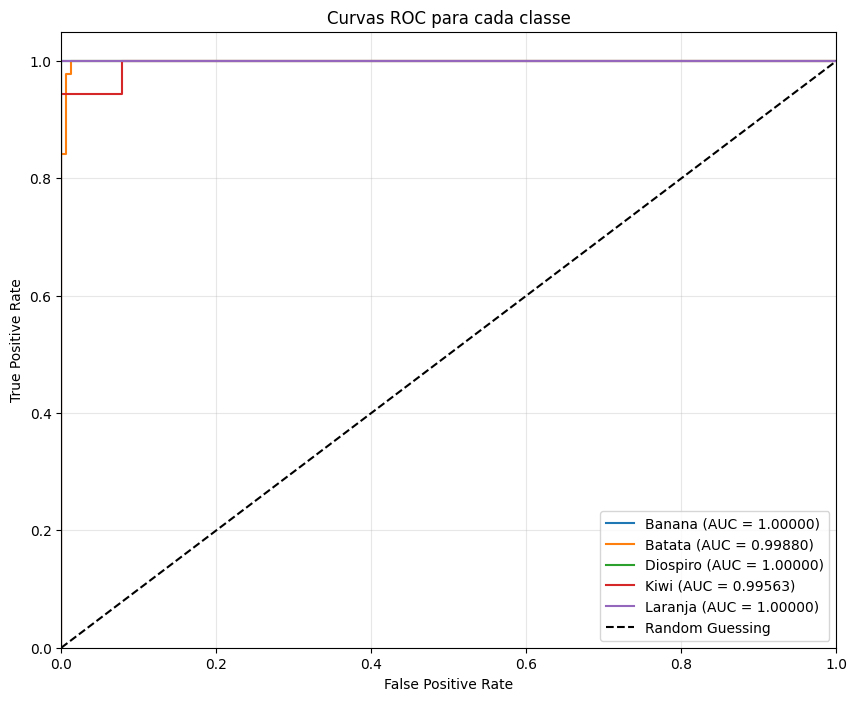

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Obter previsões para o conjunto de teste
y_true = []
y_pred_proba = []

for images, labels in test_set:
    predictions = model.predict(images)
    y_pred_proba.extend(predictions)  # Probabilidades preditas
    y_true.extend(labels.numpy())     # Labels reais

# Converter listas para arrays
y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)

# Binarizar os rótulos se necessário
if y_true.shape[1] != len(class_names):
    y_true = label_binarize(y_true, classes=range(len(class_names)))

# Plotar as curvas ROC para cada classe
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])  # FPR e TPR
    roc_auc = auc(fpr, tpr)  # Área sob a curva

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.5f})')

# Configurar o gráfico
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')  # Linha de referência
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC para cada classe')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def test_confusion_matrix(model, test_set, class_names):

    # labels e previsões
    y_true = []
    y_pred = []

    for images, labels in test_set:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))  # Previsão da classe


        if labels.shape[-1] > 1:
            y_true.extend(np.argmax(labels, axis=1))
        else:
            y_true.extend(labels.numpy())

    # lista para array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Generate classification report
    print("\n Relatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # matrix de confusão
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Matriz de Confusão")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

 Relatório de Classificação:
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        39
      Batata       0.97      0.84      0.90        44
    Diospiro       1.00      1.00      1.00        32
        Kiwi       0.71      0.94      0.81        18
     Laranja       1.00      1.00      1.00        63

    accuracy                           0.96       196
   macro avg       0.94      0.96      0.94       196
weighted avg       0.97      0.96      0.96       196



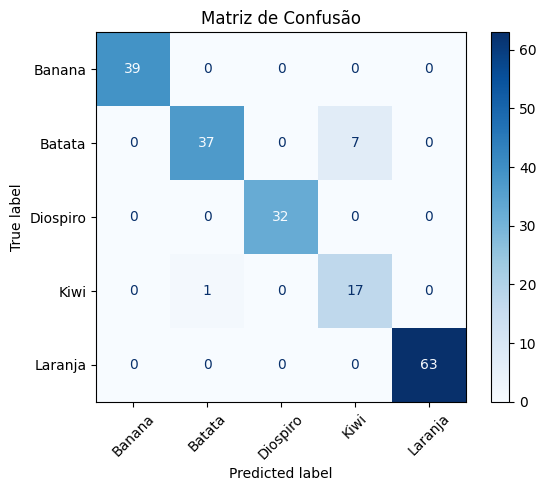

In [ ]:
test_confusion_matrix(model, test_set, class_names)

##Carregar Modelo Treinado

In [ ]:
# utilizando keras é necessário compilar o modelo antes de carregar os pesos
# o modelo tem de ser exatamente o mesmo

# inicializar modelo
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False  # congelar o modelo

# adicionar uma nova layer de saída ao modelo, para classificar as classes corretas
model_load_weights = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(5, activation='softmax')  # 2 classes
])

# compilar modelo
model_load_weights.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_load_weights.build(input_shape=(None, 320, 320, 3))

# carregar pesos
model_load_weights.load_weights("/content/model_checkpoint.keras")

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted class: Banana with confidence: 99.96%


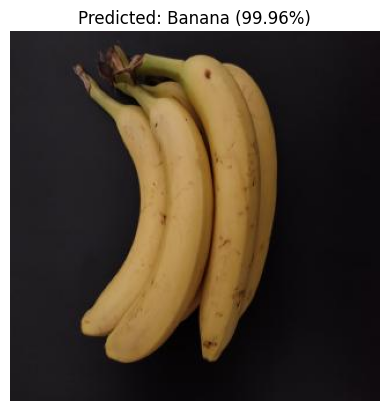

In [ ]:
# caminho da imagem
image_path = "/content/Frutas/test/Banana/IMG_20241124_125759_edit_27525857861373_jpg.rf.91859fcb9f892f46d0f276b4876cb8e0.jpg"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


##Técnicas de XAI

As técnicas de XAI, como o LIME e Grad-cam, permitem explicar os processos/resultados de IA para os seres humanos comuns. Com base nisto, esta secção extra foi feita para explicar as decisões feitas pelo nosso Modelo.

**LIME:**

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e92daf2cf62b54a1f687e1075babcbab2f843139581cb54b762b5680bf385c4a
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━

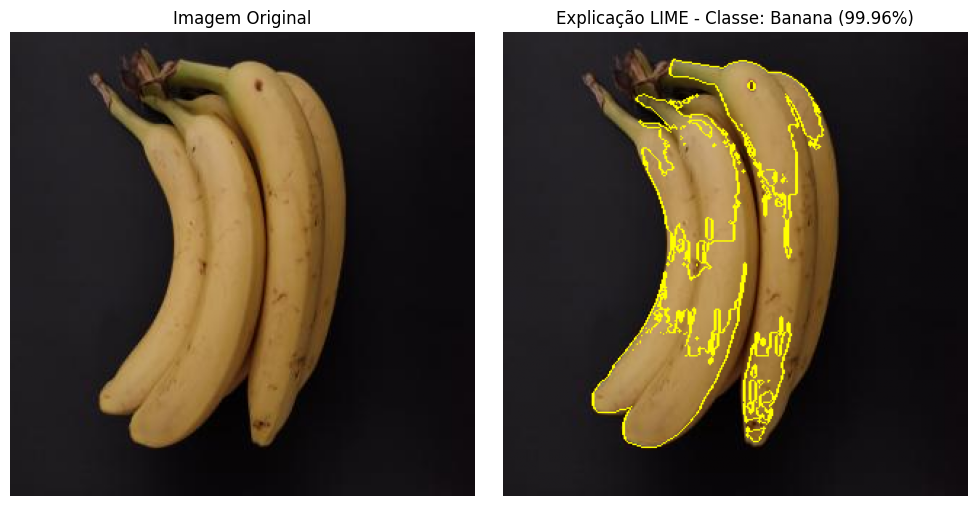

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/Frutas/test/Banana/IMG_20241124_125759_edit_27525857861373_jpg.rf.91859fcb9f892f46d0f276b4876cb8e0.jpg"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()